# 📊 01 — Exploratory Data Analysis
**Dataset:** Taiwan Credit Card Default (OpenML)  
**Output:** `data/01_raw.csv` — renamed columns, ready for next notebook

---
### Data Flow
```
fetch_openml → rename columns → EDA → save data/01_raw.csv
```


In [ ]:

import warnings; warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

os.makedirs('../data',          exist_ok=True)
os.makedirs('plots',            exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42


## 1. Load & Rename Columns

In [ ]:

COLUMN_RENAME = {
    'x1':  'LIMIT_BAL', 'x2':  'SEX',      'x3':  'EDUCATION',
    'x4':  'MARRIAGE',  'x5':  'AGE',       'x6':  'PAY_0',
    'x7':  'PAY_2',     'x8':  'PAY_3',     'x9':  'PAY_4',
    'x10': 'PAY_5',     'x11': 'PAY_6',
    'x12': 'BILL_AMT1', 'x13': 'BILL_AMT2', 'x14': 'BILL_AMT3',
    'x15': 'BILL_AMT4', 'x16': 'BILL_AMT5', 'x17': 'BILL_AMT6',
    'x18': 'PAY_AMT1',  'x19': 'PAY_AMT2',  'x20': 'PAY_AMT3',
    'x21': 'PAY_AMT4',  'x22': 'PAY_AMT5',  'x23': 'PAY_AMT6',
}

data = fetch_openml(name='default-of-credit-card-clients', version=1, as_frame=True, parser='auto')
df   = data.frame.copy()
df.rename(columns={**COLUMN_RENAME, 'y': 'DEFAULT'}, inplace=True)
df['DEFAULT'] = df['DEFAULT'].astype(int)

# Convert all categoricals to numeric
for col in df.select_dtypes(include=['category', 'object']).columns:
    df[col] = df[col].astype(float).astype(int)

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()


Shape   : (30000, 24)
Columns : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Basic Statistics

In [ ]:

print("─── Missing values ───────────────────────────────────────────")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ No missing values found")

print("\n─── Shape ────────────────────────────────────────────────────")
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")

print("\n─── Data types ───────────────────────────────────────────────")
print(df.dtypes.value_counts())


─── Missing values ───────────────────────────────────────────
✅ No missing values found

─── Shape ────────────────────────────────────────────────────
Rows: 30,000  |  Columns: 24

─── Data types ───────────────────────────────────────────────
int64    24
Name: count, dtype: int64


In [ ]:
df.describe().round(2)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00


## 3. Target Distribution

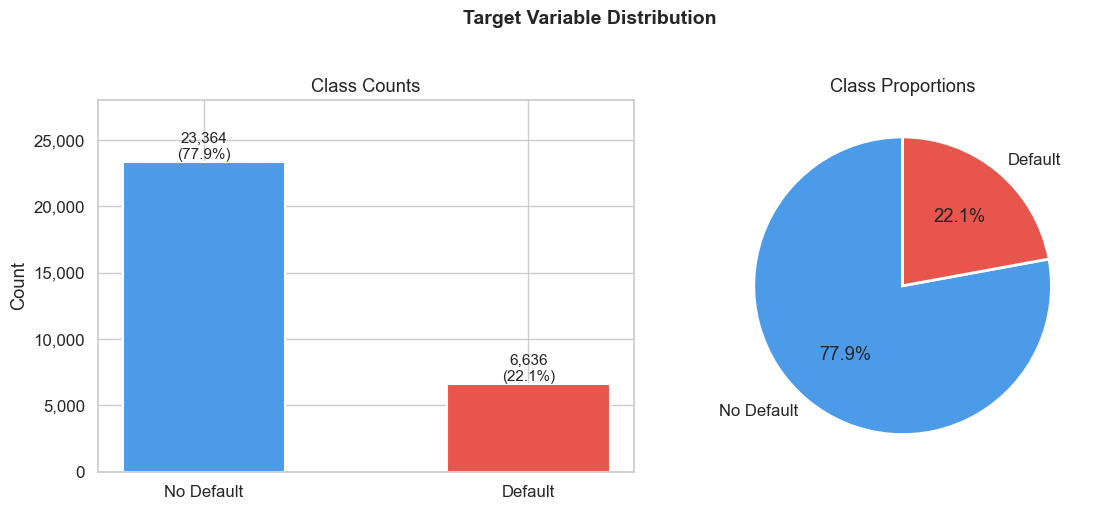

⚠️  Class imbalance — Default rate: 22.1%


In [ ]:

import matplotlib.ticker as mticker

counts = df['DEFAULT'].value_counts().sort_index()
labels = ['No Default', 'Default']
colors = ['#4C9BE8', '#E8554C']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)

# Bar
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white',
                   linewidth=1.5, width=0.5)
axes[0].set_ylim(0, max(counts.values) * 1.2)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Counts')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"⚠️  Class imbalance — Default rate: {counts[1]/len(df):.1%}")


## 4. Numeric Feature Distributions

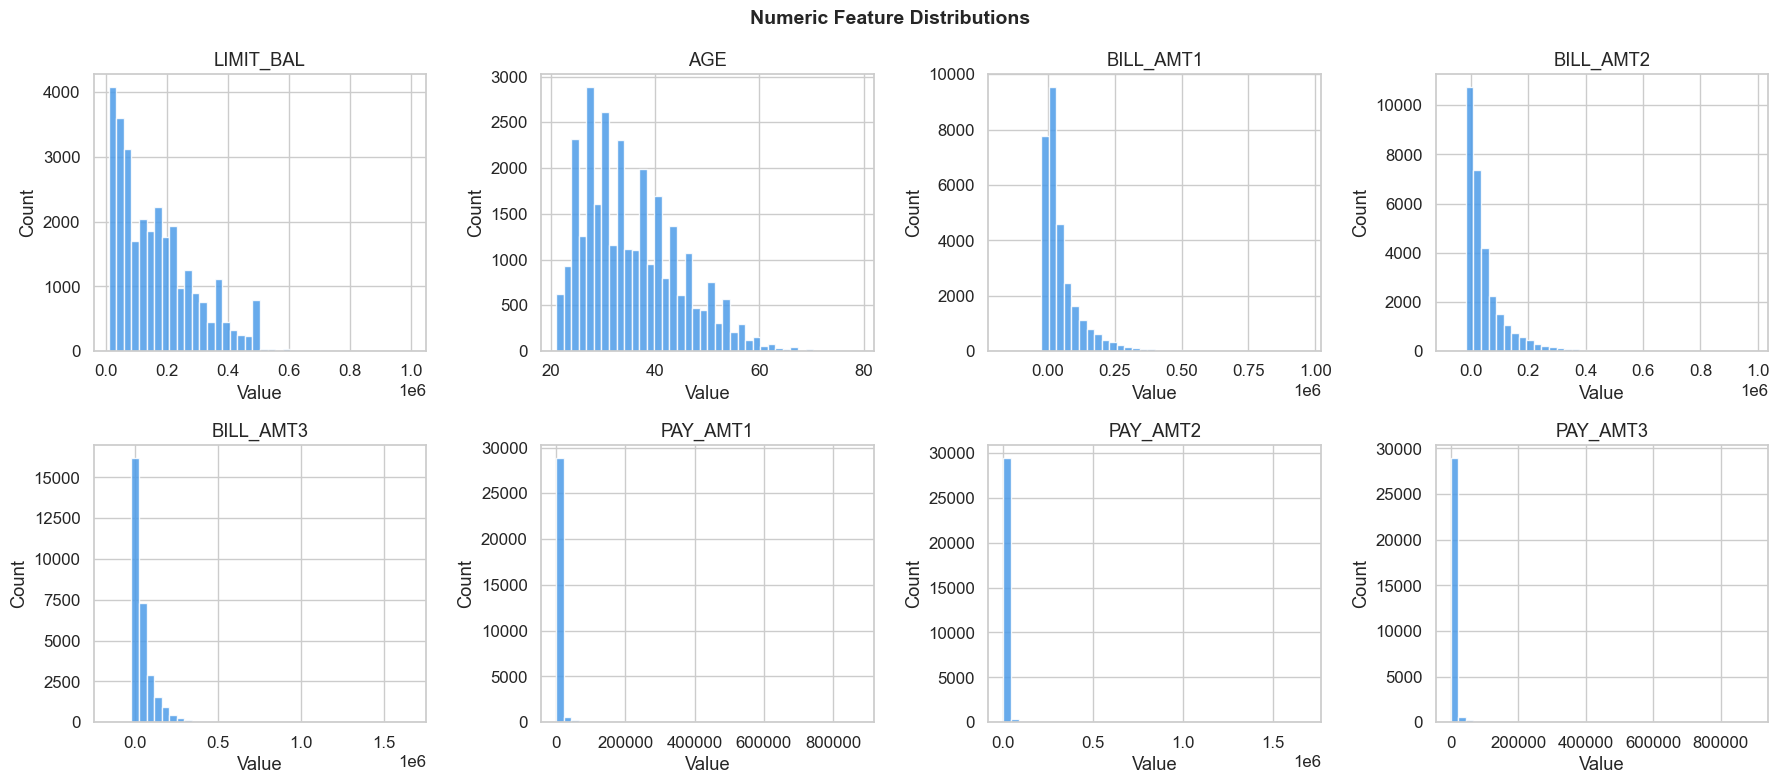

In [ ]:

NUMERIC_COLS = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
                'BILL_AMT3', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flatten(), NUMERIC_COLS):
    ax.hist(df[col], bins=40, color='#4C9BE8', edgecolor='white', alpha=0.85)
    ax.set_title(col); ax.set_xlabel('Value'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plots/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Default Rate by Category

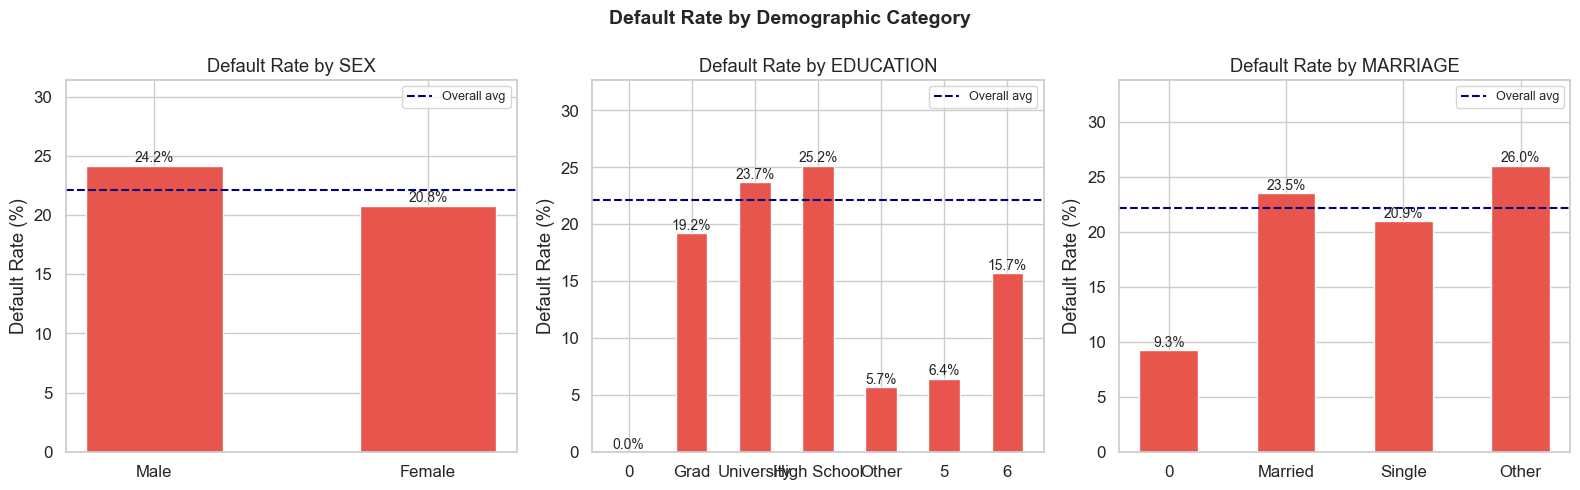

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Default Rate by Demographic Category', fontsize=14, fontweight='bold')

configs = [
    ('SEX',       {1: 'Male', 2: 'Female'}),
    ('EDUCATION', {1: 'Grad', 2: 'University', 3: 'High School', 4: 'Other'}),
    ('MARRIAGE',  {1: 'Married', 2: 'Single', 3: 'Other'}),
]

for ax, (col, label_map) in zip(axes, configs):
    rates  = df.groupby(col)['DEFAULT'].mean() * 100
    xlbls  = [label_map.get(k, str(k)) for k in rates.index]
    bars   = ax.bar(xlbls, rates.values, color='#E8554C', edgecolor='white', width=0.5)
    ax.axhline(df['DEFAULT'].mean() * 100, color='navy', linestyle='--',
               linewidth=1.5, label='Overall avg')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate (%)')
    ax.set_ylim(0, rates.max() * 1.3)
    ax.legend(fontsize=9)
    for bar, v in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
                f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('plots/01_default_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Correlation Heatmap

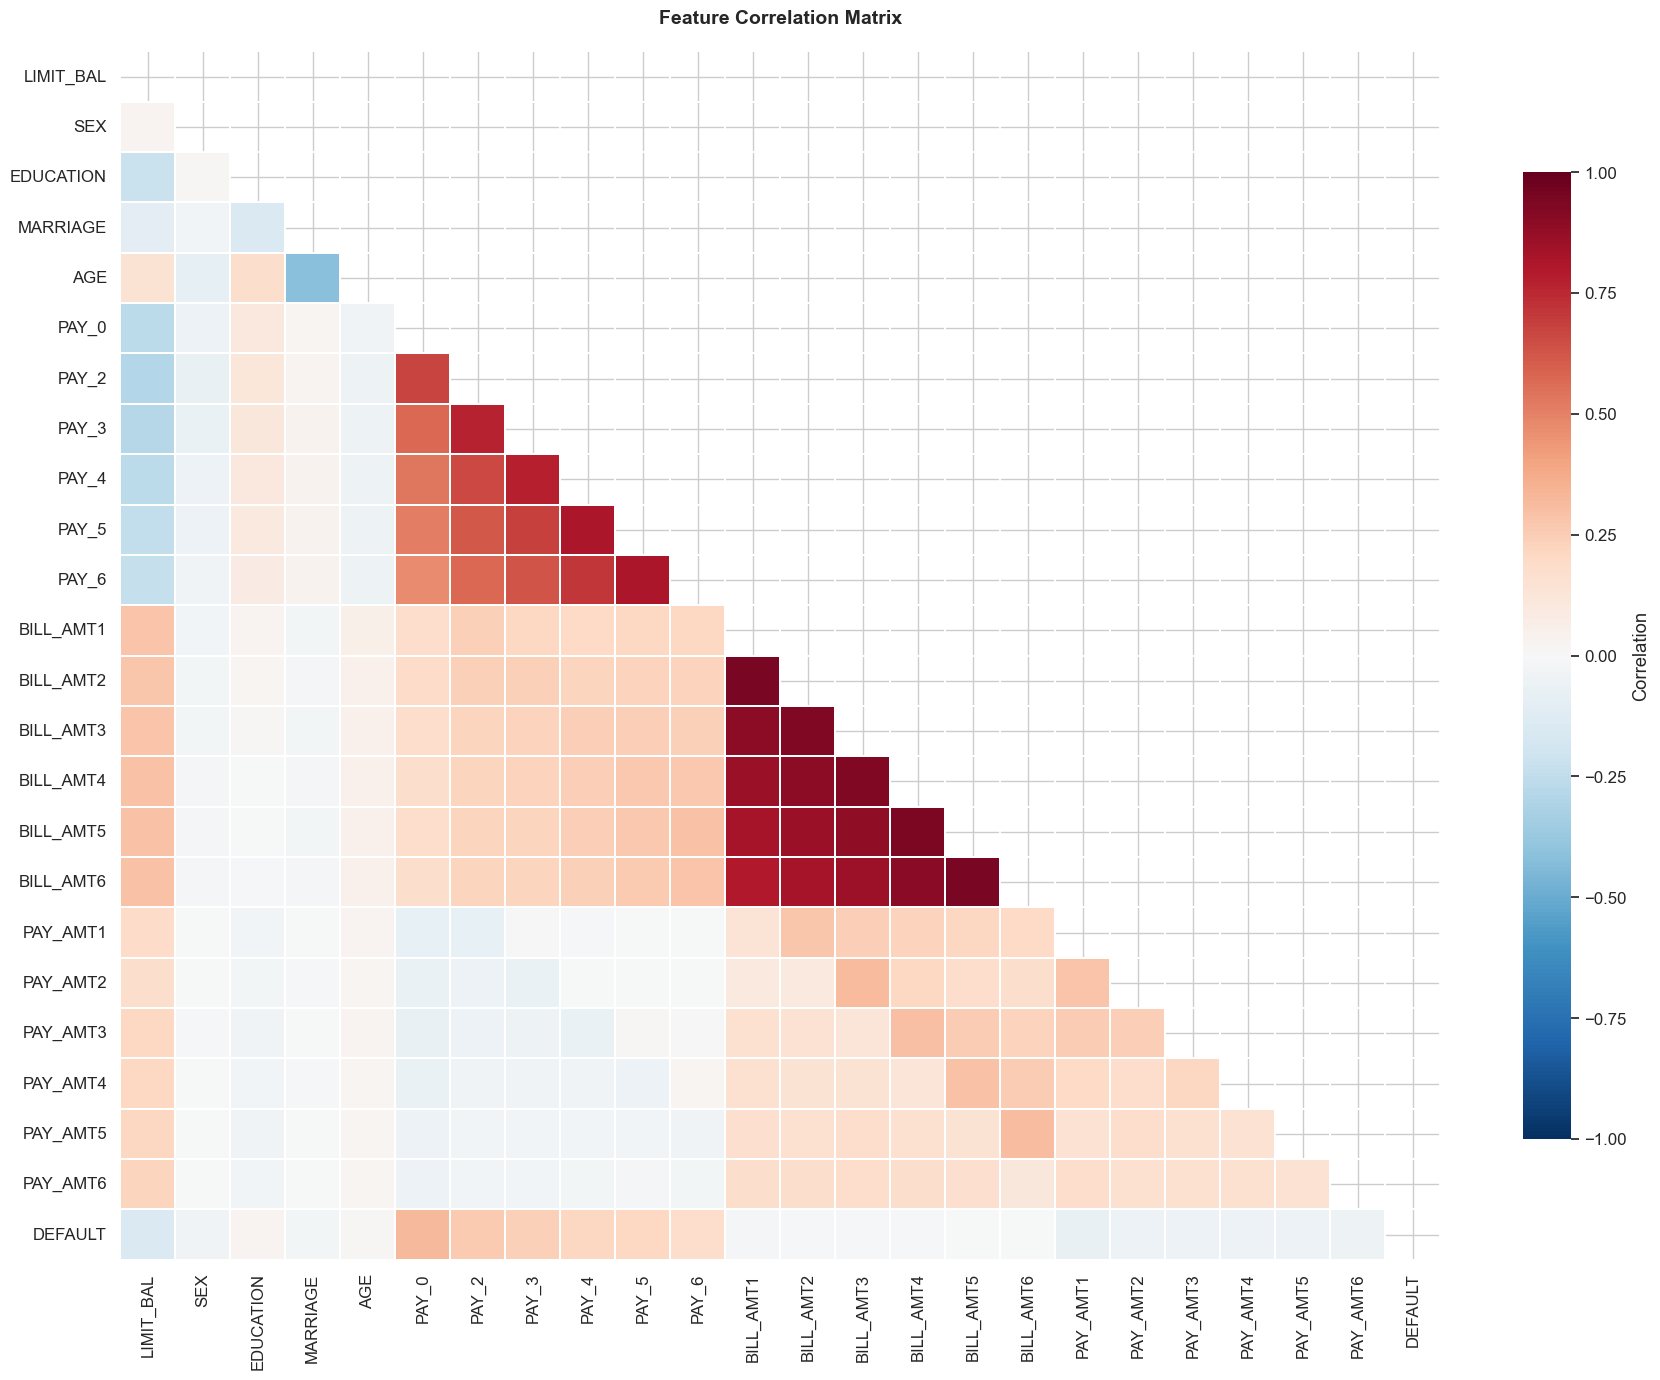


Top 10 features correlated with DEFAULT:
PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL    0.1535
PAY_AMT1     0.0729
PAY_AMT2     0.0586
PAY_AMT4     0.0568
Name: DEFAULT, dtype: float64


In [ ]:

corr = df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features correlated with DEFAULT:")
print(corr['DEFAULT'].drop('DEFAULT').abs().sort_values(ascending=False).head(10).round(4))


## 7. Outlier Detection

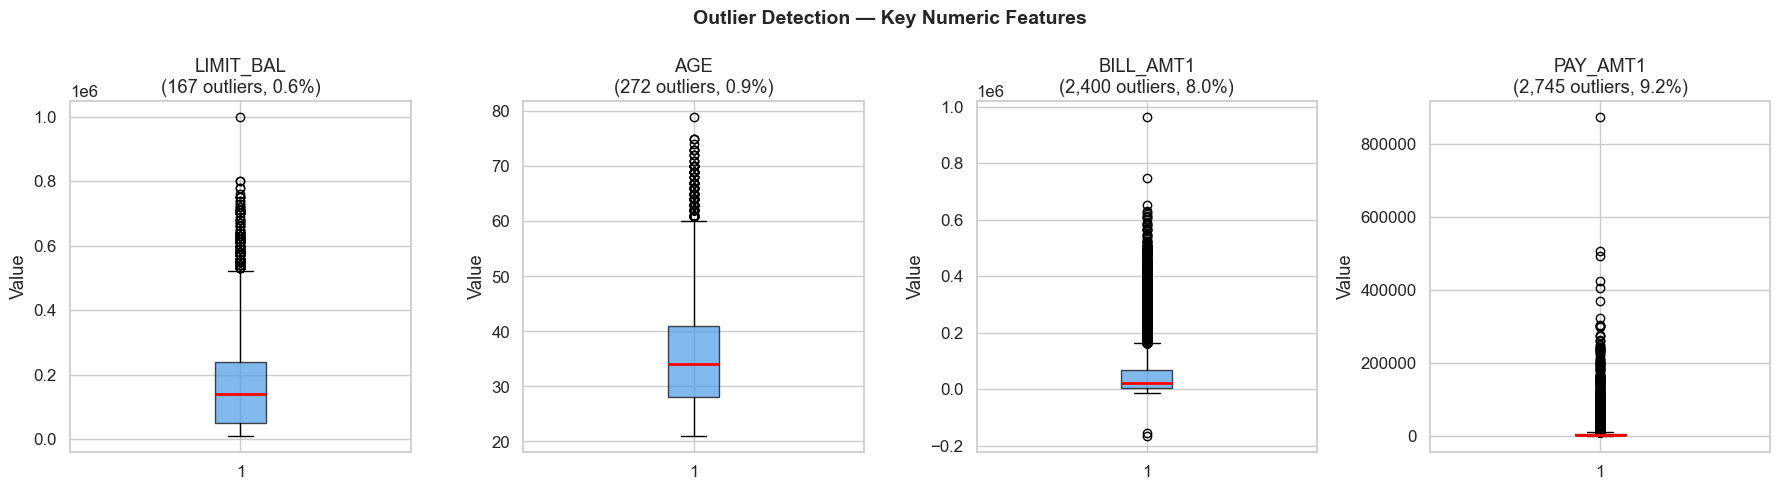

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Outlier Detection — Key Numeric Features', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']):
    ax.boxplot(df[col], patch_artist=True,
               boxprops={'facecolor': '#4C9BE8', 'alpha': 0.7},
               medianprops={'color': 'red', 'linewidth': 2})
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    n_out   = len(df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)])
    ax.set_title(f'{col}\n({n_out:,} outliers, {n_out/len(df):.1%})')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('plots/01_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## ✅ Save Dataset

In [ ]:

out_path = '../data/01_raw.csv'
df.to_csv(out_path, index=False)
print(f"✅ Saved: {out_path}")
print(f"   Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"   Columns: {df.columns.tolist()}")


✅ Saved: ../data/01_raw.csv
   Rows: 30,000  |  Columns: 24
   Columns: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']

➡️  Next notebook loads from: data/01_raw.csv
